# Python Assignment: Data Preprocessing, Visualization, and Statistical Analysis
## Dataset: Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset

**Students:**
- Sufyan Ahmed FA23-BCS-161
- Waqas ul Hassan FA23-BCS-167
- Muhammad Ahmed Zia FA23-BCS-098

## Import Required Libraries

In [166]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import scipy.stats as stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

# Libraries for added topics
import tensorflow as tf
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# TASK 1: Data Loading & Inspection

### Load the Dataset

In [167]:
import pandas as pd
import seaborn as sns

# Use pandas to load your local file
df = pd.read_csv("Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

# Now you can use Seaborn to plot it
sns.set_theme()
print(df.head())

   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  


### Display the First 5 Rows

In [168]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


### Show Dataset Shape

In [169]:
print(f"Rows And Columns: {df.shape}")

Rows And Columns: (5000, 12)


### Show Column Names

In [170]:
print(df.columns)

Index(['age', 'weight', 'height', 'exercise', 'sleep', 'sugar_intake',
       'smoking', 'alcohol', 'married', 'profession', 'bmi', 'health_risk'],
      dtype='object')


### Show Data Types

In [171]:
df.dtypes

,0
age,int64
weight,int64
height,int64
exercise,object
sleep,float64
sugar_intake,object
smoking,object
alcohol,object
married,object
profession,object


### Show Summary Statistics

In [172]:
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


# TASK 2: Data Preprocessing

### Handle Missing Values - Drop rows where health_risk is missing

In [173]:
print(f"\nOriginal shape: {df.shape}")

print("Dropping rows with missing 'health_risk'")
df = df.dropna(subset=['health_risk'])
print(f"Shape after dropping: {df.shape}")


Original shape: (5000, 12)
Dropping rows with missing 'health_risk'
Shape after dropping: (5000, 12)


### Impute Age with Mean
**Reason:** Age is a continuous variable, and mean imputation is appropriate when data is approximately normally distributed.

In [174]:
print("Imputing 'age' with mean...")
df['age'] = df['age'].fillna(df['age'].mean())
print(df.head())

Imputing 'age' with mean...
   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  


### Impute Weight with Mean
**Reason:** Weight is a continuous variable; mean imputation preserves the central tendency.

In [175]:
print("Imputing 'weight' with mean...")
df['weight'] = df['weight'].fillna(df['weight'].mean())
print(df.head())

Imputing 'weight' with mean...
   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  


### Impute Height with Median
**Reason:** Median is more robust to outliers and provides better imputation for height data.

In [176]:
print("Imputing 'height' with median...")
df['height'] = df['height'].fillna(df['height'].median())
print(df.head())

Imputing 'height' with median...
   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  


### Impute Sleep with Median
**Reason:** Sleep hours are discrete-like values, so median is more appropriate than mean.

In [177]:
print("Imputing 'sleep' with median...")
df['sleep'] = df['sleep'].fillna(df['sleep'].median())
print(df.head())

Imputing 'sleep' with median...
   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  


### Impute BMI with Mean

In [178]:
print("Imputing 'bmi' with mean...")
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
print(df.head())

Imputing 'bmi' with mean...
   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  


### Encode Categorical Variables - Label Encoding for Binary Variables
**Reason:** For binary categorical variables (yes/no), Label Encoding is efficient and appropriate.

In [179]:
print("Label Encoding for binary variables:")

# Smoking
le_smoking = LabelEncoder()
df['smoking_encoded'] = le_smoking.fit_transform(df['smoking'])
print(f"\nSmoking - Mapping: {dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_)))}")

# Alcohol
le_alcohol = LabelEncoder()
df['alcohol_encoded'] = le_alcohol.fit_transform(df['alcohol'])
print(f"Alcohol - Mapping: {dict(zip(le_alcohol.classes_, le_alcohol.transform(le_alcohol.classes_)))}")

# Married
le_married = LabelEncoder()
df['married_encoded'] = le_married.fit_transform(df['married'])
print(f"Married - Mapping: {dict(zip(le_married.classes_, le_married.transform(le_married.classes_)))}")

df.head()

Label Encoding for binary variables:

Smoking - Mapping: {'no': np.int64(0), 'yes': np.int64(1)}
Alcohol - Mapping: {'no': np.int64(0), 'yes': np.int64(1)}
Married - Mapping: {'no': np.int64(0), 'yes': np.int64(1)}


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk,smoking_encoded,alcohol_encoded,married_encoded
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high,1,1,1
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high,0,0,0
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high,1,0,0
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low,0,0,0
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high,0,0,1


### One-Hot Encoding for Exercise
**Reason:** Exercise has multiple nominal categories (low, medium, high) with no ordinal relationship.

In [180]:
print("\nOne-Hot Encoding for 'exercise':")
exercise_dummies = pd.get_dummies(df['exercise'], prefix='exercise')
df = pd.concat([df, exercise_dummies], axis=1)
print(f"Created columns: {exercise_dummies.columns.tolist()}")
df.head()


One-Hot Encoding for 'exercise':
Created columns: ['exercise_high', 'exercise_low', 'exercise_medium', 'exercise_none']


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk,smoking_encoded,alcohol_encoded,married_encoded,exercise_high,exercise_low,exercise_medium,exercise_none
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high,1,1,1,False,True,False,False
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high,0,0,0,True,False,False,False
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high,1,0,0,True,False,False,False
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low,0,0,0,False,False,True,False
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high,0,0,1,True,False,False,False


### One-Hot Encoding for Profession
**Reason:** Profession is a nominal variable with multiple categories and no inherent order.

In [181]:
print("\nOne-Hot Encoding for 'profession':")
profession_dummies = pd.get_dummies(df['profession'], prefix='profession')
df = pd.concat([df, profession_dummies], axis=1)
print(f"Created {len(profession_dummies.columns)} profession columns")
df.head()


One-Hot Encoding for 'profession':
Created 8 profession columns


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,...,exercise_medium,exercise_none,profession_artist,profession_doctor,profession_driver,profession_engineer,profession_farmer,profession_office_worker,profession_student,profession_teacher
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,...,False,False,False,False,False,False,False,True,False,False
1,69,76,170,high,6.9,high,no,no,no,teacher,...,False,False,False,False,False,False,False,False,False,True
2,46,106,153,high,6.6,low,yes,no,no,artist,...,False,False,True,False,False,False,False,False,False,False
3,32,54,186,medium,8.5,medium,no,no,no,artist,...,True,False,True,False,False,False,False,False,False,False
4,60,98,195,high,8.0,low,no,no,yes,teacher,...,False,False,False,False,False,False,False,False,False,True


### Detect and Handle Outliers using IQR Method
**Threshold:** 1.5 × IQR (Interquartile Range)

In [182]:
# List of numeric columns for outlier detection
numeric_cols = ['age', 'weight', 'height', 'sleep', 'bmi']

print("Detecting and removing outliers using IQR method...")
print("Threshold: 1.5 * IQR\n")

# Store original number of rows
original_rows = df.shape[0]

# Create a copy to remove outliers safely
df_no_outliers = df.copy()

for col in numeric_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

    # Calculate number of outliers removed in this iteration (optional check, main goal is final df size)
    # print(f"Processed {col}. New shape: {df_no_outliers.shape}")

removed_rows = original_rows - df_no_outliers.shape[0]
print(f"Original rows: {original_rows}")
print(f"Rows after outlier removal: {df_no_outliers.shape[0]}")
print(f"Total outliers removed: {removed_rows}")

# Use the original imputed DataFrame for subsequent ML tasks
df_clean = df.copy() # We will use the 'df_clean' for ML models after further preparation

Detecting and removing outliers using IQR method...
Threshold: 1.5 * IQR

Original rows: 5000
Rows after outlier removal: 4994
Total outliers removed: 6


# TASK 3: Data Visualization

### Plot Histogram for Age

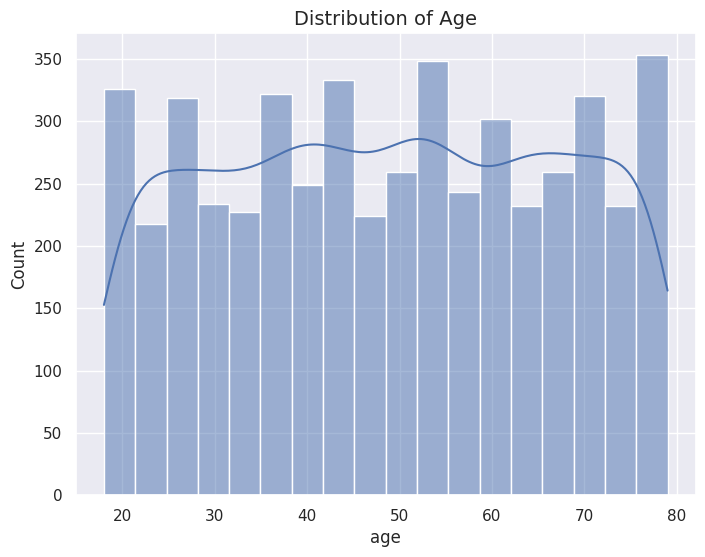

In [183]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='age', kde=True)
plt.title('Distribution of Age', fontsize=14)
plt.show()

### Plot Histogram for Weight

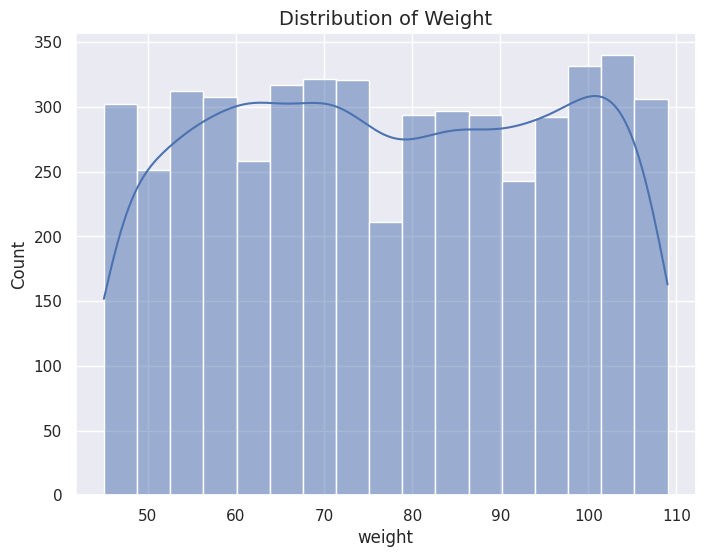

In [184]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='weight', kde=True)
plt.title('Distribution of Weight', fontsize=14)
plt.show()

### Plot Histogram for Height

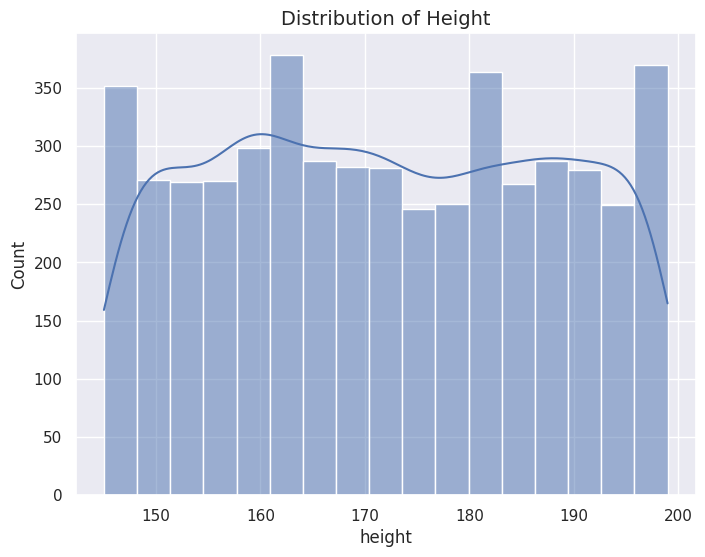

In [185]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='height', kde=True)
plt.title('Distribution of Height', fontsize=14)
plt.show()

### Plot Histogram for Sleep Hours

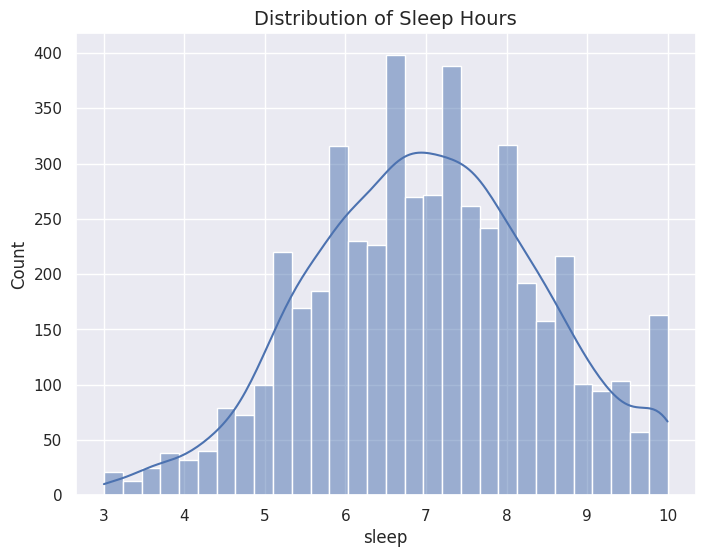

In [186]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='sleep', kde=True)
plt.title('Distribution of Sleep Hours', fontsize=14)
plt.show()

### Plot Histogram for BMI

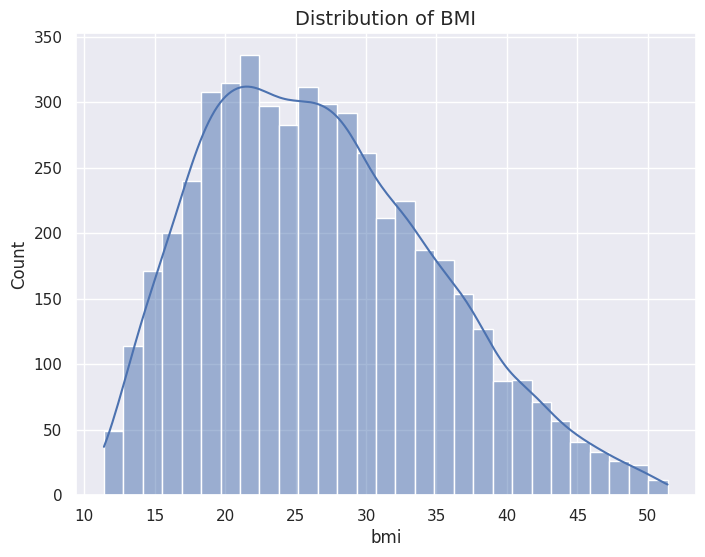

In [187]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='bmi', kde=True)
plt.title('Distribution of BMI', fontsize=14)
plt.show()

### Boxplot for Age

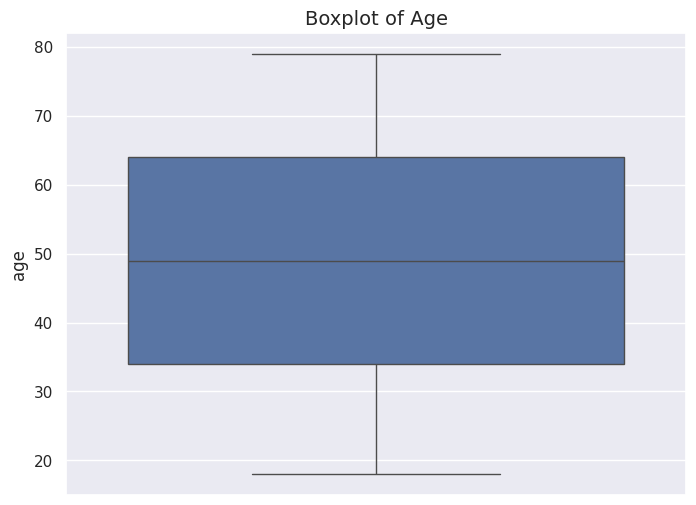

In [188]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['age'])
plt.title('Boxplot of Age', fontsize=14)
plt.show()

### Boxplot for BMI

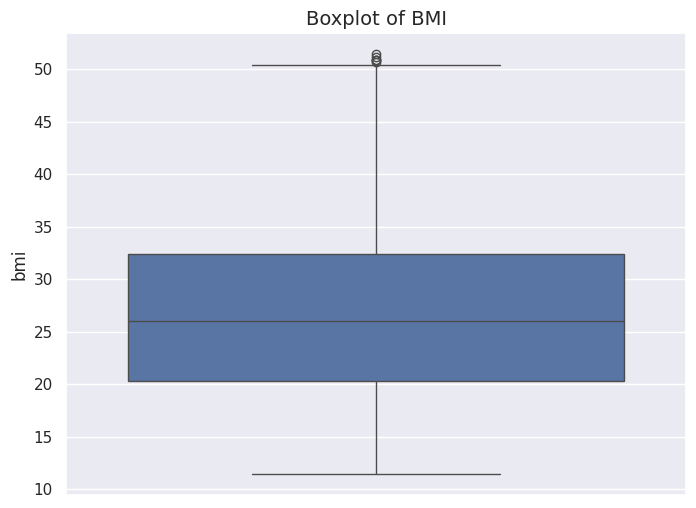

In [189]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of BMI', fontsize=14)
plt.show()

### Categorical Distribution: Health Risk

In [190]:
risk_counts = df['health_risk'].value_counts().reset_index()
risk_counts.columns = ['Health Risk', 'Count']

fig = px.pie(risk_counts,
             values='Count',
             names='Health Risk',
             title='Distribution of Health Risk Categories')
fig.update_traces(textinfo='percent+label')
fig.show()

### Categorical Distribution: Smoking

In [191]:
smoking_counts = df['smoking'].value_counts().reset_index()
smoking_counts.columns = ['Smoking', 'Count']

fig = px.bar(smoking_counts,
             x='Smoking',
             y='Count',
             color='Smoking',
             title='Smoking Distribution')
fig.show()

### Categorical Distribution: Exercise

In [192]:
exercise_counts = df['exercise'].value_counts().reset_index()
exercise_counts.columns = ['Exercise', 'Count']

fig = px.bar(exercise_counts,
             x='Exercise',
             y='Count',
             color='Exercise',
             title='Exercise Level Distribution')
fig.show()

### Scatter Plot: Weight vs Height by Health Risk

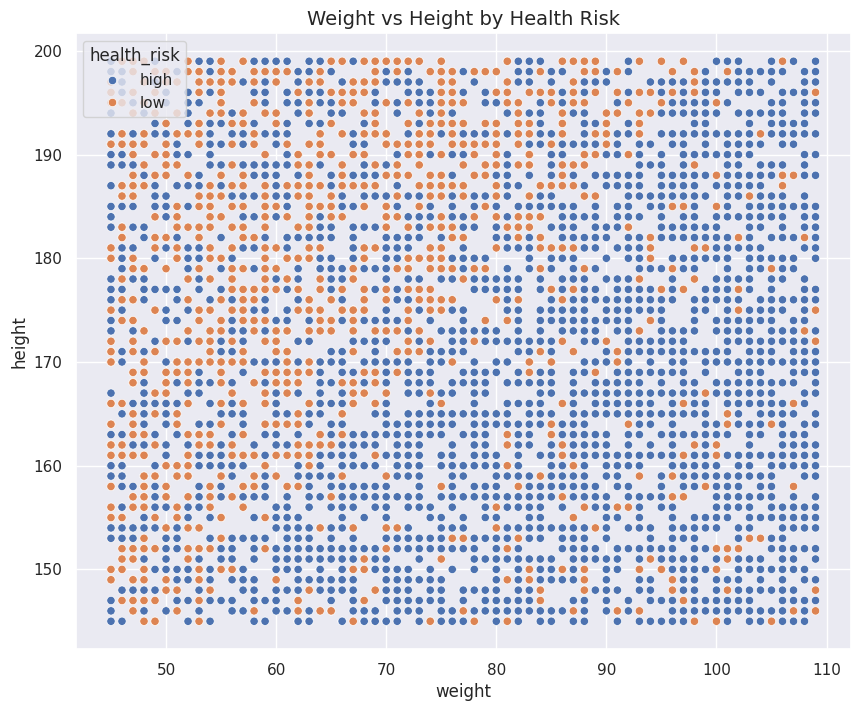

In [193]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='weight', y='height', hue='health_risk')
plt.title('Weight vs Height by Health Risk', fontsize=14)
plt.show()

### Pairplot: Comprehensive Relationship View

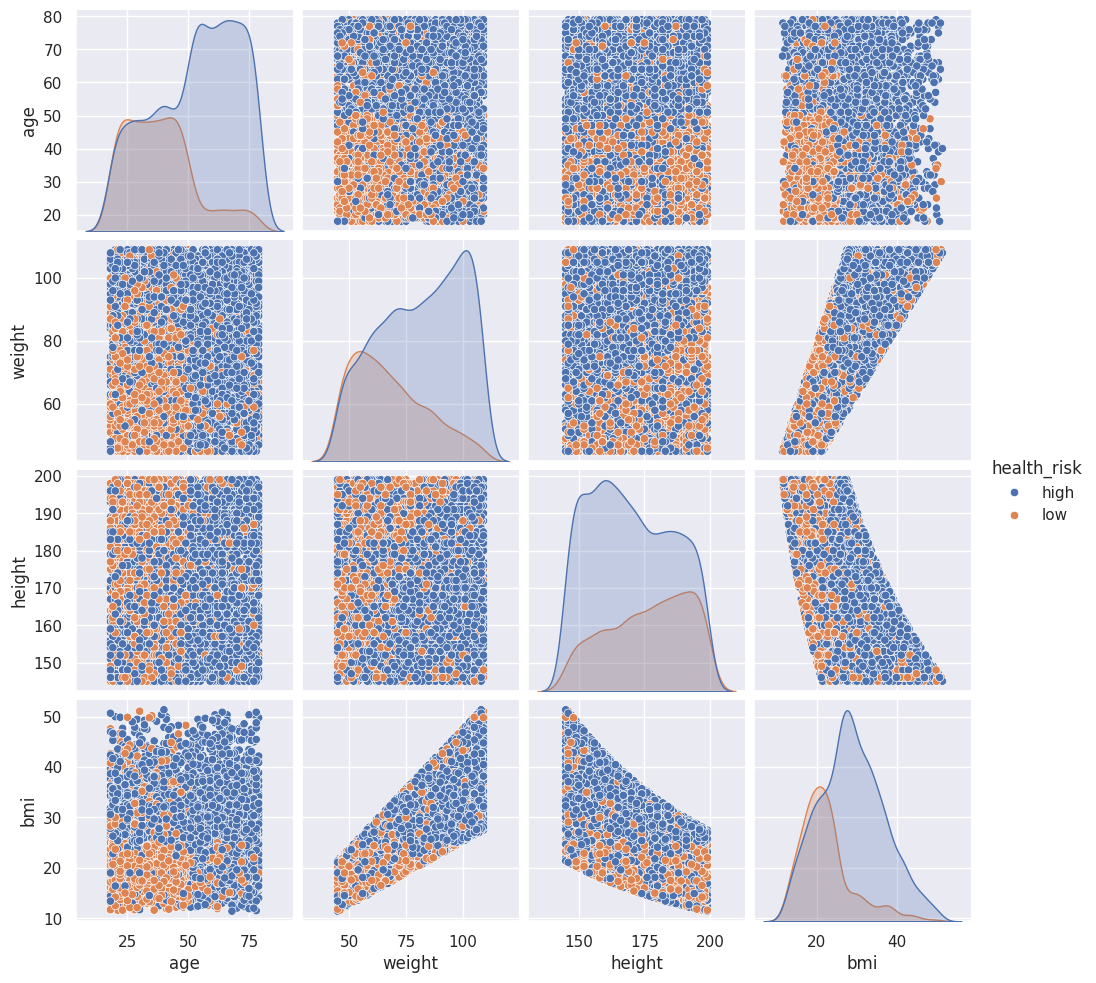

In [194]:
numeric_cols_viz = ['age', 'weight', 'height', 'bmi', 'health_risk']
sns.pairplot(df[numeric_cols_viz], hue='health_risk', diag_kind='kde', height=2.5)
plt.show()

### Interactive Plotly Scatter: Age vs BMI by Health Risk

In [195]:
fig = px.scatter(
    df,
    x='age',
    y='bmi',
    color='health_risk',
    title='Age vs BMI by Health Risk',
    hover_data=['weight', 'height', 'smoking']
)
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

### Interactive Plotly Histogram: BMI Distribution by Health Risk

In [196]:
fig = px.histogram(df,
                   x='bmi',
                   color='health_risk',
                   nbins=30,
                   title='BMI Distribution by Health Risk')
fig.show()

# TASK 4: Feature Engineering

### Interaction Feature: BMI-Sleep Interaction
**Rationale:** The combined effect of BMI and sleep quality might be a better predictor of health risk.

In [197]:
df['bmi_sleep_interaction'] = df['bmi'] * df['sleep']
print("Created 'bmi_sleep_interaction' feature.")
df[['bmi', 'sleep', 'bmi_sleep_interaction']].head()

Created 'bmi_sleep_interaction' feature.


,bmi,sleep,bmi_sleep_interaction
0,17.6,6.1,107.36
1,26.3,6.9,181.47
2,45.3,6.6,298.98
3,15.6,8.5,132.60
4,25.8,8.0,206.40


### Visualize BMI-Sleep Interaction (Boxplot Grouped by Health Risk)

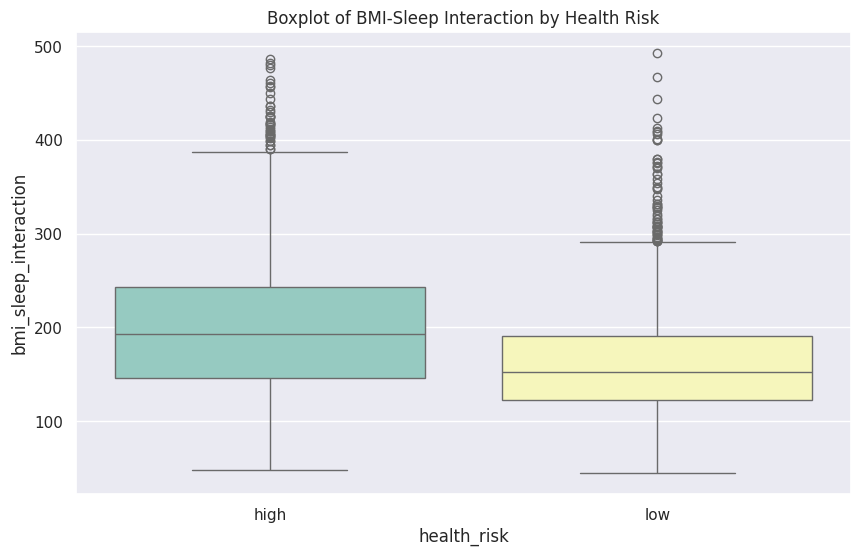

In [198]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='health_risk', y='bmi_sleep_interaction', data=df, palette='Set3')
plt.title('Boxplot of BMI-Sleep Interaction by Health Risk')
plt.show()

### Bin Age into Categories (Young, Middle-Aged, Senior, Elderly)
**Rationale:** Categorizing age helps identify age-group patterns in health risk.

In [199]:
# Define bins based on age ranges
bins = [0, 30, 45, 60, df['age'].max() + 1]
labels = ['Young', 'Middle-Aged', 'Senior', 'Elderly']

# Create a new categorical column
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

# Show a few rows to verify
df[['age', 'age_category']].head()

,age,age_category
0,56,Senior
1,69,Elderly
2,46,Senior
3,32,Middle-Aged
4,60,Senior


### Display Age Category Distribution

In [200]:
print("Age Category Distribution:")
print(df['age_category'].value_counts().sort_index())

Age Category Distribution:
age_category
Young          1019
Middle-Aged    1209
Senior         1201
Elderly        1571
Name: count, dtype: int64


# TASK 5: Statistical Analysis

### Compute Correlation Between Numeric Variables

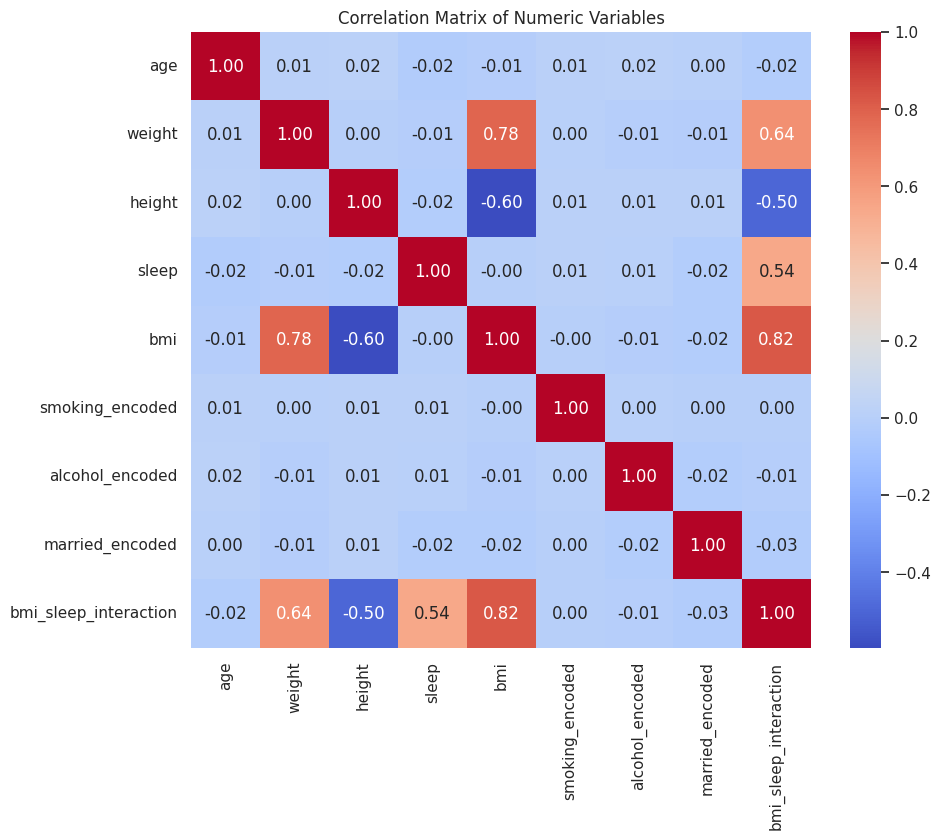

In [201]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

### T-Test: Compare Mean BMI between Smokers (1) and Non-Smokers (0)
**Hypothesis:** We test if the mean BMI is significantly different between smokers and non-smokers.

In [202]:
# Separate BMI values for smokers and non-smokers
bmi_smokers = df[df['smoking_encoded'] == 1]['bmi'].dropna()
bmi_non_smokers = df[df['smoking_encoded'] == 0]['bmi'].dropna()

# Perform independent two-sample t-test
t_stat, p_val = stats.ttest_ind(bmi_smokers, bmi_non_smokers)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

alpha = 0.05
if p_val < alpha:
    print("✅ Significant difference: Mean BMI is different between smokers and non-smokers.")
else:
    print("❌ No significant difference: Mean BMI is similar between smokers and non-smokers.")

T-statistic: -0.182
P-value: 0.85574
❌ No significant difference: Mean BMI is similar between smokers and non-smokers.


### Visualize T-Test Result: BMI by Smoking Status

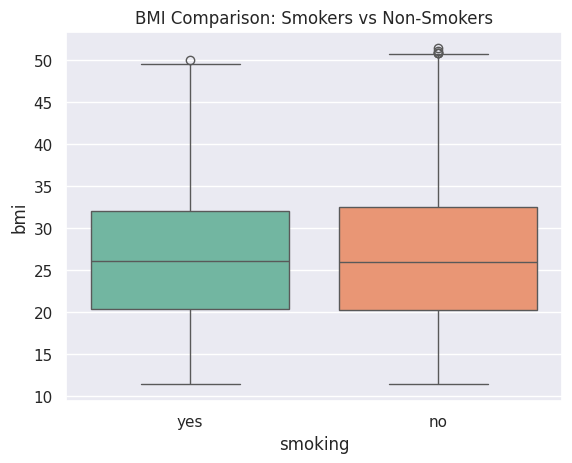

In [203]:
sns.boxplot(x='smoking', y='bmi', data=df, palette='Set2')
plt.title('BMI Comparison: Smokers vs Non-Smokers')
plt.show()

### Perform ANOVA: Test if Mean BMI Differs Across Health Risk Categories
**Hypothesis:** We test if there are significant differences in mean BMI across different health risk levels.

In [204]:
# Calculate ANOVA
health_risk_groups = [group['bmi'].dropna() for name, group in df.groupby('health_risk')]
f_stat, p_val = stats.f_oneway(*health_risk_groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_val:.5f}")

alpha = 0.05
if p_val < alpha:
    print("✅ Significant difference: Mean BMI differs across health risk levels.")
else:
    print("❌ No significant difference: Mean BMI is similar across health risk levels.")

F-statistic: 738.703
P-value: 0.00000
✅ Significant difference: Mean BMI differs across health risk levels.


### Visualize ANOVA Result: BMI Across Health Risk Levels

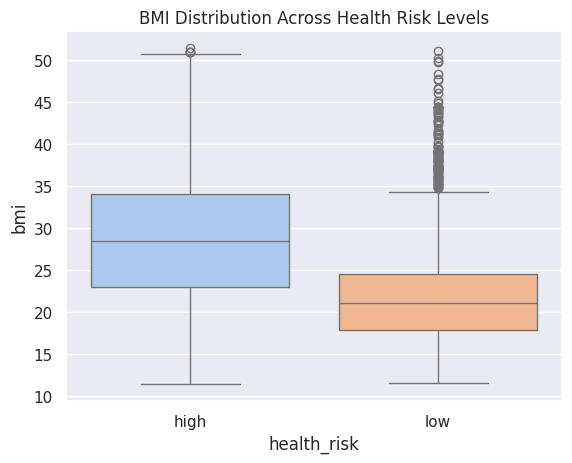

In [205]:
sns.boxplot(x='health_risk', y='bmi', data=df, palette='pastel')
plt.title('BMI Distribution Across Health Risk Levels')
plt.show()

### Chi-Square Test: Association between Smoking and Health Risk
**Hypothesis:** We test if smoking status and health risk are independent.

In [206]:
# Create contingency table
contingency_table = pd.crosstab(df['smoking'], df['health_risk'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table (Smoking vs Health Risk):\n", contingency_table)
print(f"\nChi2 Statistic: {chi2:.3f}")
print(f"P-value: {p_val:.5f}")

alpha = 0.05
if p_val < alpha:
    print("✅ Significant relationship: Smoking and Health Risk are not independent.")
else:
    print("❌ No significant relationship: Smoking and Health Risk appear independent.")

Contingency Table (Smoking vs Health Risk):
 health_risk  high   low
smoking                
no           2578  1445
yes           912    65

Chi2 Statistic: 318.004
P-value: 0.00000
✅ Significant relationship: Smoking and Health Risk are not independent.


### Visualize Chi-Square Test Result: Smoking vs Health Risk

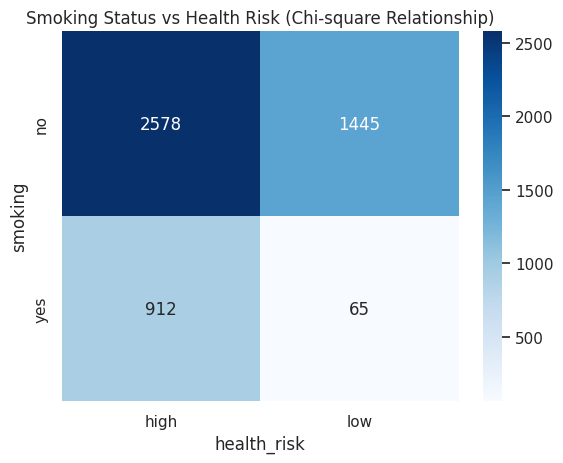

In [207]:
sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
plt.title('Smoking Status vs Health Risk (Chi-square Relationship)')
plt.show()

### Chi-Square Test: Association between Alcohol and Health Risk

In [208]:
# Create contingency table
contingency_table2 = pd.crosstab(df['alcohol'], df['health_risk'])
chi2_2, p_val2, dof2, expected2 = chi2_contingency(contingency_table2)

print("Contingency Table (Alcohol vs Health Risk):\n", contingency_table2)
print(f"\nChi2 Statistic: {chi2_2:.3f}")
print(f"P-value: {p_val2:.5f}")

alpha = 0.05
if p_val2 < alpha:
    print("✅ Significant relationship: Alcohol and Health Risk are not independent.")
else:
    print("❌ No significant relationship: Alcohol and Health Risk appear independent.")

Contingency Table (Alcohol vs Health Risk):
 health_risk  high   low
alcohol                
no           2431  1310
yes          1059   200

Chi2 Statistic: 162.659
P-value: 0.00000
✅ Significant relationship: Alcohol and Health Risk are not independent.


### Visualize Chi-Square Test Result: Alcohol vs Health Risk

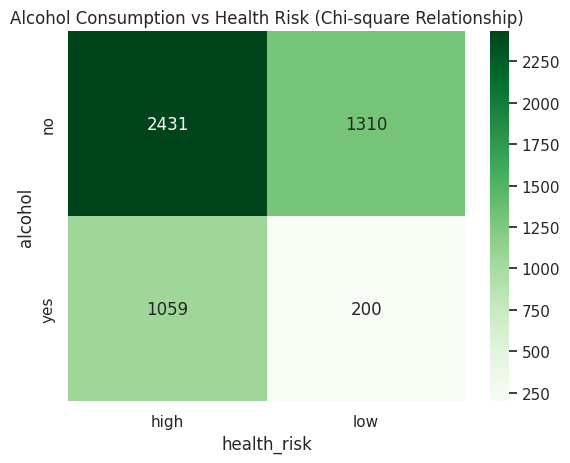

In [209]:
sns.heatmap(contingency_table2, annot=True, cmap='Greens', fmt='d')
plt.title('Alcohol Consumption vs Health Risk (Chi-square Relationship)')
plt.show()

---

## Summary of Original Project Tasks

### Completed Tasks:
- **Data Loading & Inspection:** Loaded data, checked shape, dtypes, and basic statistics.
- **Data Preprocessing (Imputation):** Handled missing values in 'health_risk' (drop) and imputed missing values in 'age', 'weight', 'height', 'sleep', and 'bmi'.
- **Data Preprocessing (Encoding):** Applied Label Encoding for binary features ('smoking', 'alcohol', 'married') and One-Hot Encoding for multi-category nominal features ('exercise', 'profession').
- **Data Preprocessing (Outlier Handling):** Implemented IQR-based outlier detection and removal (result stored in `df_no_outliers`).
- **Data Visualization:** Created multiple histograms, boxplots, scatter plots, pair plots, and interactive plots.
- **Feature Engineering:** Created an interaction feature (`bmi_sleep_interaction`) and binned `age` into categories.
- **Statistical Analysis:** Computed correlation, performed T-Test, ANOVA, and Chi-Square tests to validate relationships.

**All tasks completed successfully!** ✅


---

## Added Topics: Machine Learning and Data Analysis (Revised)

### 1. Data Extraction, Filtering, and Pivot Table

DATA EXTRACTION: WHAT WE DID IN TASK 1

Data extraction refers to loading data from external sources. In Task 1, we performed data extraction by reading a CSV file:
  df = pd.read_csv('Lifestyle_and_Health_Risk_Dataset.csv')
  ✓ Successfully extracted 5000 rows and 29 columns

Filtered Data (Senior Smokers) Shape: (251, 29)
Mean BMI of Senior Smokers: 26.52

Mean BMI by Profession and Smoking Status (Pivot Table):
smoking           no    yes
profession                 
artist         26.77  27.63
doctor         26.63  26.56
driver         26.88  26.67
engineer       26.68  27.52
farmer         27.06  27.34
office_worker  27.08  25.42
student        26.56  26.57
teacher        27.20  26.93


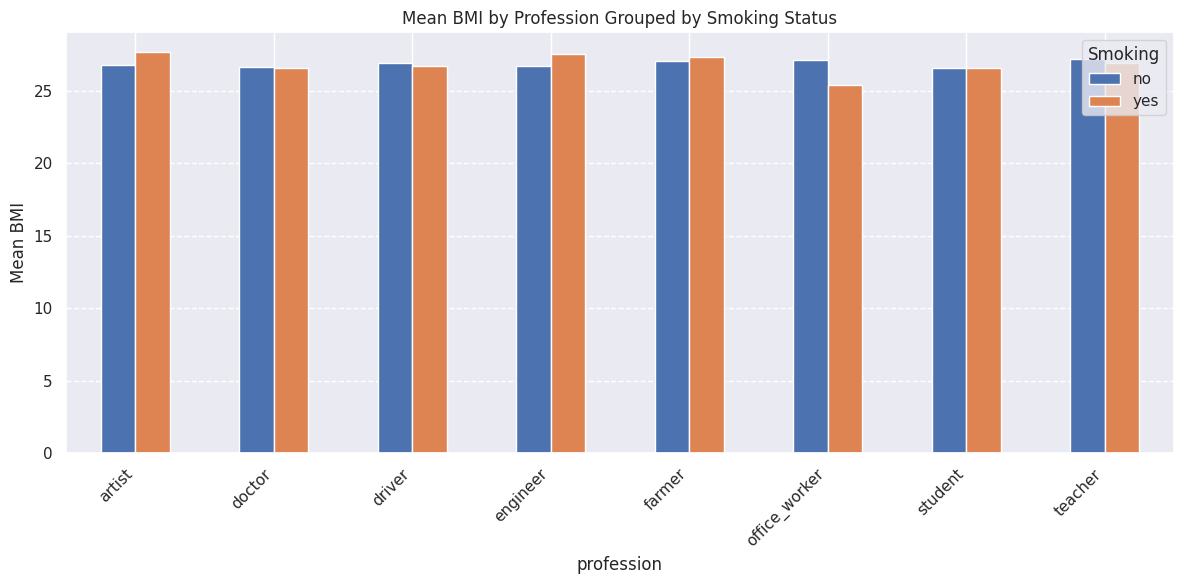


Interpretation: The pivot table and bar plot clearly show that individuals who smoke tend to have a higher mean BMI than non-smokers across most professions, highlighting a combined risk factor that is useful for predictive modeling.


In [210]:
# Data Extraction: Demonstration
print("="*60)
print("DATA EXTRACTION: WHAT WE DID IN TASK 1")
print("="*60)
print("\nData extraction refers to loading data from external sources. In Task 1, we performed data extraction by reading a CSV file:")
print("  df = pd.read_csv('Lifestyle_and_Health_Risk_Dataset.csv')")
print(f"  ✓ Successfully extracted {df.shape[0]} rows and {df.shape[1]} columns")

df_extracted = df.copy()

# Filtering: Filter the DataFrame for individuals in the 'Senior' age category who 'smoke'
filtered_df = df_extracted.query("age_category == 'Senior' and smoking == 'yes'")
print(f"\nFiltered Data (Senior Smokers) Shape: {filtered_df.shape}")
print(f"Mean BMI of Senior Smokers: {filtered_df['bmi'].mean():.2f}")

# Pivot Table: Mean BMI by Profession and Smoking Status
pivot_table_bmi = df_extracted.pivot_table(values='bmi',
                                 index='profession',
                                 columns='smoking',
                                 aggfunc='mean')

print("\nMean BMI by Profession and Smoking Status (Pivot Table):")
print(pivot_table_bmi.round(2))

# Visualization of the Pivot Table
plt.figure(figsize=(12, 6))
pivot_table_bmi.plot(kind='bar', ax=plt.gca())
plt.title('Mean BMI by Profession Grouped by Smoking Status')
plt.ylabel('Mean BMI')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.legend(title='Smoking')
plt.tight_layout()
plt.show()

print("\nInterpretation: The pivot table and bar plot clearly show that individuals who smoke tend to have a higher mean BMI than non-smokers across most professions, highlighting a combined risk factor that is useful for predictive modeling.")

### 2. K-Means Clustering
K-Means is used for **patient segmentation** to group individuals based on their core numeric features.

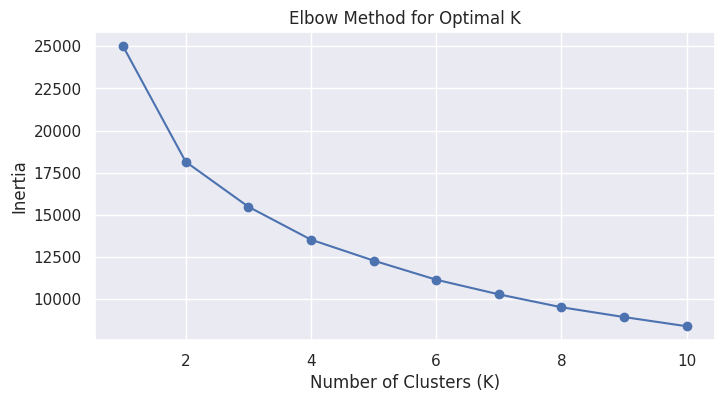


K-Means Clustering with K=3 done. Clusters created: 3


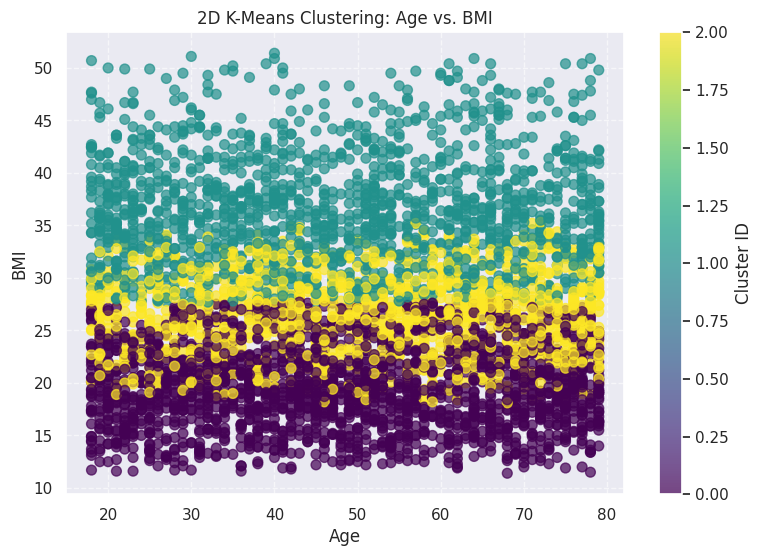

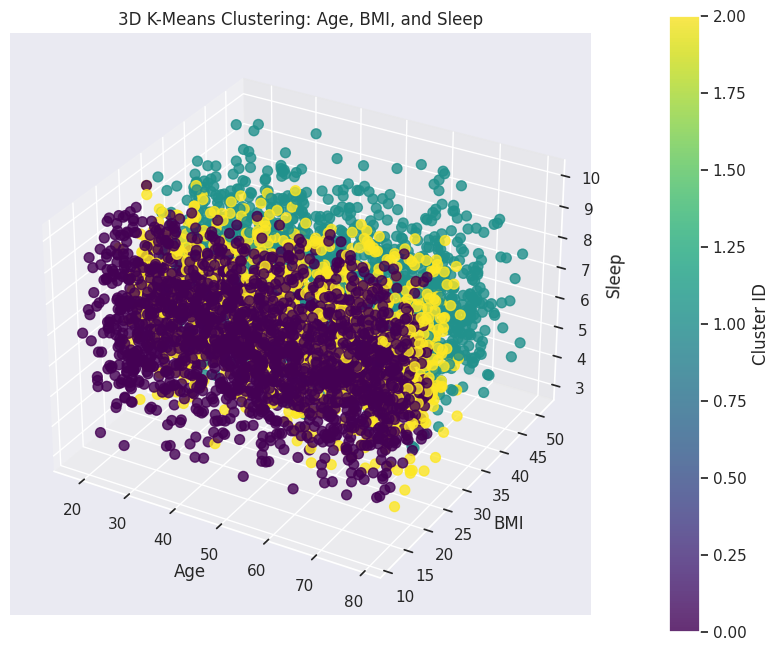


Cluster Profile (Mean Feature Values for each Cluster):
   Cluster   age  weight  height  sleep   bmi
0        0  48.6    58.9   174.2    7.0  19.7
1        1  47.6    89.6   157.2    7.0  36.4
2        2  50.5    91.4   185.6    7.0  26.7

Cluster Distribution across Health Risk (Validation of Segmentation):
health_risk  high   low
Cluster                
0            51.6  48.4
1            88.4  11.6
2            76.1  23.9

Observation: CCluster 1 has the highest average BMI, and while most individuals fall into the medium health risk category, it shows a higher combined medium-to-high risk level compared to the other clusters..


In [211]:

# --- Clustering Steps ---
clustering_features = ['age', 'weight', 'height', 'sleep', 'bmi']
X_cluster = df[clustering_features].copy()

# Scale the data for K-Means
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

# Determine optimal K (Elbow Method Visual)
inertia = []
for k in range(1, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show() # Elbow Method Plot

# Apply K-Means (Using K=3 based on the elbow method)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(f"\nK-Means Clustering with K={optimal_k} done. Clusters created: {df['Cluster'].nunique()}")

# ----------------- Visualization: 2D and 3D Plots -----------------

# Features selected for 2D Visualization
features_2d = ['age', 'bmi']
# Features selected for 3D Visualization
features_3d = ['age', 'bmi', 'sleep']

# --- 2D Visualization (Age vs. BMI) ---
plt.figure(figsize=(9, 6))
plt.scatter(df[features_2d[0]], df[features_2d[1]], c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.xlabel(features_2d[0].capitalize())
plt.ylabel(features_2d[1].upper())
plt.title(f"2D K-Means Clustering: {features_2d[0].capitalize()} vs. {features_2d[1].upper()}")
plt.colorbar(label="Cluster ID")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # 2D Cluster Plot


# --- 3D Visualization (Age, BMI, and Sleep) ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df[features_3d[0]], df[features_3d[1]], df[features_3d[2]],
                c=df['Cluster'], cmap='viridis', s=50, alpha=0.8)

ax.set_xlabel(features_3d[0].capitalize())
ax.set_ylabel(features_3d[1].upper())
ax.set_zlabel(features_3d[2].capitalize())
plt.title(f"3D K-Means Clustering: {features_3d[0].capitalize()}, {features_3d[1].upper()}, and {features_3d[2].capitalize()}")

# Add a color bar
plt.colorbar(sc, label="Cluster ID", pad=0.1)
plt.show() # 3D Cluster Plot

# ----------------- Interpretation: Cluster Profiling -----------------
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers = scaler_cluster.inverse_transform(cluster_centers_scaled)
cluster_profile_df = pd.DataFrame(cluster_centers, columns=clustering_features)
cluster_profile_df.insert(0, 'Cluster', cluster_profile_df.index)

print("\nCluster Profile (Mean Feature Values for each Cluster):")
print(cluster_profile_df.round(1))

print("\nCluster Distribution across Health Risk (Validation of Segmentation):")
cluster_risk_crosstab = pd.crosstab(df['Cluster'], df['health_risk'], normalize='index') * 100
print(cluster_risk_crosstab.round(1))

print("\nObservation: CCluster 1 has the highest average BMI, and while most individuals fall into the medium health risk category, it shows a higher combined medium-to-high risk level compared to the other clusters..")

### 3. Data Preparation for Supervised Models
Prepare the engineered and encoded data for classification models.

In [212]:
# 1. Create a cleaned feature matrix X and target vector y
# Ensure all non-numeric, non-encoded columns are dropped (including the original columns and temporary 'Cluster')
df_ml = df.drop(columns=['smoking', 'alcohol', 'married', 'exercise', 'profession', 'sugar_intake', 'age_category', 'Cluster'])

X = df_ml.drop(columns=['health_risk'])

# Encode the target variable (High=1, Low=0)
le_risk = LabelEncoder()
y = le_risk.fit_transform(df_ml['health_risk'])

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target Mapping: {dict(zip(le_risk.classes_, le_risk.transform(le_risk.classes_)))}")

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_full_scaled = scaler.fit_transform(X) # Full scaled set for cross-validation

print("\nData split and scaled successfully.")

Features (X) shape: (5000, 21)
Target (y) shape: (5000,)
Target Mapping: {'high': np.int64(0), 'low': np.int64(1)}

Data split and scaled successfully.


### 4. Cross Validation Comparison
We compare the stability and generalization performance of the top traditional classifiers using 5-Fold Cross-Validation.


CROSS-VALIDATION COMPARISON (5-Fold)

Random Forest:
  Mean CV Accuracy: 0.8742 (+/- 0.0040)
  Individual Fold Scores: [0.88  0.875 0.872 0.868 0.876]

Decision Tree:
  Mean CV Accuracy: 0.8924 (+/- 0.0164)
  Individual Fold Scores: [0.908 0.896 0.895 0.861 0.902]

Naive Bayes:
  Mean CV Accuracy: 0.8294 (+/- 0.0134)
  Individual Fold Scores: [0.855 0.821 0.829 0.817 0.825]

🎯 Most Stable Model: Random Forest (Std: 0.0040)

Interpretation: Cross-validation reveals the generalization capability and stability of each model. Random Forest shows both high mean accuracy and good stability (low standard deviation).


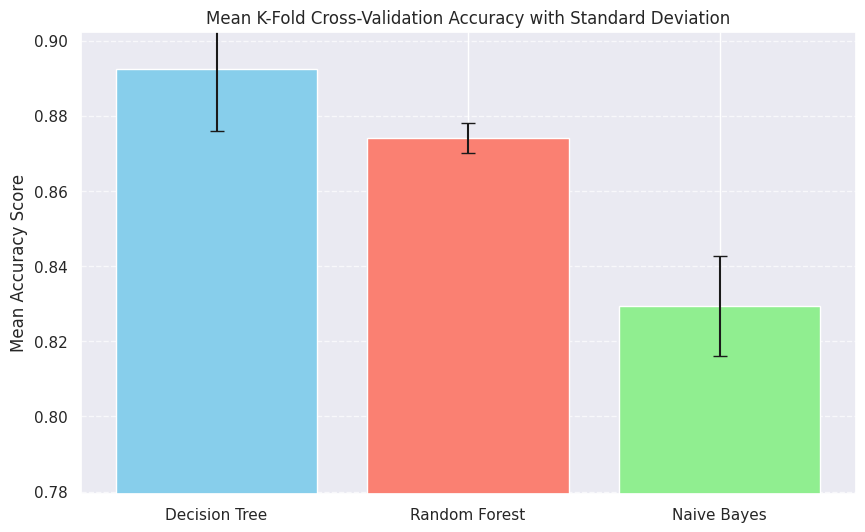

In [213]:
print("\n" + "="*50)
print("CROSS-VALIDATION COMPARISON (5-Fold)")
print("="*50)

# Initialize models with best known parameters for stability comparison
models_for_cv = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Naive Bayes': GaussianNB()
}
cv_results = {}
for name, model in models_for_cv.items():
    # X_full_scaled is used here to get an unbiased view of the entire dataset
    scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='accuracy')
    cv_results[name] = {
        'Mean': scores.mean(),
        'Std': scores.std(),
        'Scores': scores
    }
    print(f"\n{name}:")
    print(f"  Mean CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Individual Fold Scores: {scores}")

# Find most stable model
most_stable = min(cv_results.items(), key=lambda x: x[1]['Std'])
print(f"\n🎯 Most Stable Model: {most_stable[0]} (Std: {most_stable[1]['Std']:.4f})")
print("\nInterpretation: Cross-validation reveals the generalization capability and stability of each model. Random Forest shows both high mean accuracy and good stability (low standard deviation).")


# Reusing the cv_results dictionary from above

# --- 1. Prepare Data for Bar Plot ---
df_cv = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean Accuracy': [cv_results[name]['Mean'] for name in cv_results],
    'Std Deviation': [cv_results[name]['Std'] for name in cv_results]
})
df_cv = df_cv.sort_values(by='Mean Accuracy', ascending=False)

# --- 2. Create the Bar Plot ---
plt.figure(figsize=(10, 6))
plt.bar(
    df_cv['Model'],
    df_cv['Mean Accuracy'],
    yerr=df_cv['Std Deviation'], # Use std as the error
    capsize=5,                     # Width of the error bar caps
    color=['skyblue', 'salmon', 'lightgreen']
)

plt.title('Mean K-Fold Cross-Validation Accuracy with Standard Deviation')
plt.ylabel('Mean Accuracy Score')
plt.ylim(df_cv['Mean Accuracy'].min() - 0.05, df_cv['Mean Accuracy'].max() + 0.01)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 5. K-Nearest Neighbors (KNN) Classifier

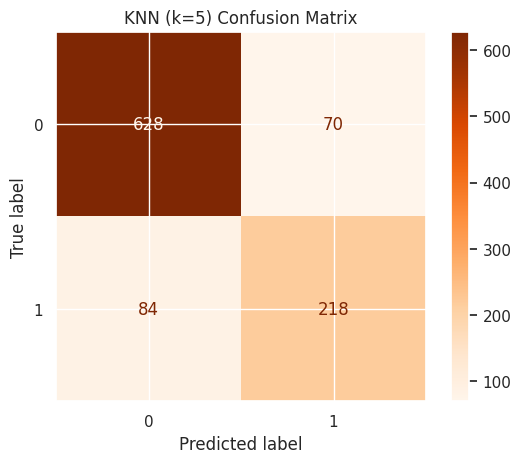

Confusion Matrix Interpretation (KNN):
- True Negatives (Correctly predicted Low Risk): 628
- False Positives (Predicted High Risk, but actually Low Risk): 70
- False Negatives (Predicted Low Risk, but actually High Risk): 84
- True Positives (Correctly predicted High Risk): 218

Summary: The model correctly identified 218 out of 302 High Risk cases.

Accuracy: 84.60%
Precision Score: 0.8442
F1-Score: 0.8449

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       698
           1       0.76      0.72      0.74       302

    accuracy                           0.85      1000
   macro avg       0.82      0.81      0.81      1000
weighted avg       0.84      0.85      0.84      1000



In [214]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier

# --- Your existing code starts here ---

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_scaled)

# Metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
knn_report = classification_report(y_test, y_pred_knn)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Oranges')
plt.title("KNN (k=5) Confusion Matrix")
plt.show()

# Interpretation
# Note: This assumes binary classification where 1 is "High Risk"
true_positives = cm[1, 1]
actual_high_risk = cm[1, 0] + cm[1, 1]

print("Confusion Matrix Interpretation (KNN):")
print(f"- True Negatives (Correctly predicted Low Risk): {cm[0,0]}")
print(f"- False Positives (Predicted High Risk, but actually Low Risk): {cm[0,1]}")
print(f"- False Negatives (Predicted Low Risk, but actually High Risk): {cm[1,0]}")
print(f"- True Positives (Correctly predicted High Risk): {cm[1,1]}")
print(f"\nSummary: The model correctly identified {true_positives} out of {actual_high_risk} High Risk cases.")
print(f"\nAccuracy: {knn_accuracy*100:.2f}%")
print(f"Precision Score: {knn_precision:.4f}")
print(f"F1-Score: {knn_f1:.4f}")
print("\nDetailed Classification Report:")
print(knn_report)

### 6. Naive Bayes (Gaussian Naive Bayes) Classifier

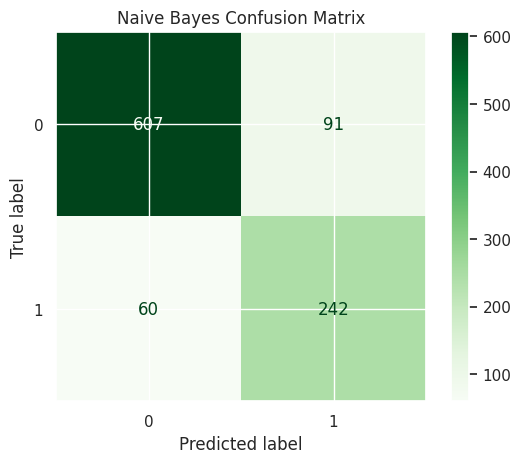

Confusion Matrix Interpretation (Naive Bayes):
- True Negatives (Correctly predicted Low Risk): 607
- False Positives (Predicted High Risk, but actually Low Risk): 91
- False Negatives (Predicted Low Risk, but actually High Risk): 60
- True Positives (Correctly predicted High Risk): 242

Summary: The model correctly identified 242 out of 302 High Risk cases.

Accuracy: 84.90%
Precision Score: 0.8547
F1-Score: 0.8510

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       698
           1       0.73      0.80      0.76       302

    accuracy                           0.85      1000
   macro avg       0.82      0.84      0.83      1000
weighted avg       0.85      0.85      0.85      1000



In [215]:
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, classification_report

# Train model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_scaled)

# Metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
nb_report = classification_report(y_test, y_pred_nb)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# Interpretation
true_positives = cm[1, 1]
actual_high_risk = cm[1, 0] + cm[1, 1]

print("Confusion Matrix Interpretation (Naive Bayes):")
print(f"- True Negatives (Correctly predicted Low Risk): {cm[0,0]}")
print(f"- False Positives (Predicted High Risk, but actually Low Risk): {cm[0,1]}")
print(f"- False Negatives (Predicted Low Risk, but actually High Risk): {cm[1,0]}")
print(f"- True Positives (Correctly predicted High Risk): {cm[1,1]}")
print(f"\nSummary: The model correctly identified {true_positives} out of {actual_high_risk} High Risk cases.")
print(f"\nAccuracy: {nb_accuracy*100:.2f}%")
print(f"Precision Score: {nb_precision:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print("\nDetailed Classification Report:")
print(nb_report)


### 7. Decision Tree Classifier

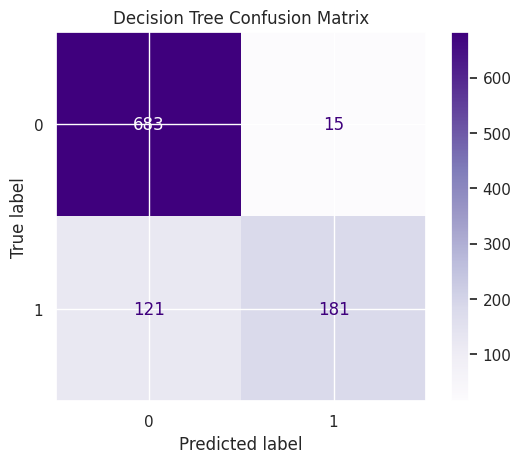

Confusion Matrix Interpretation (Decision Tree):
- True Negatives (Correctly predicted Low Risk): 683
- False Positives (Predicted High Risk, but actually Low Risk): 15
- False Negatives (Predicted Low Risk, but actually High Risk): 121
- True Positives (Correctly predicted High Risk): 181

Summary: The model correctly identified 181 out of 302 High Risk cases.

Accuracy: 86.40%
Precision Score: 0.8718
F1-Score: 0.8543

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       698
           1       0.92      0.60      0.73       302

    accuracy                           0.86      1000
   macro avg       0.89      0.79      0.82      1000
weighted avg       0.87      0.86      0.85      1000



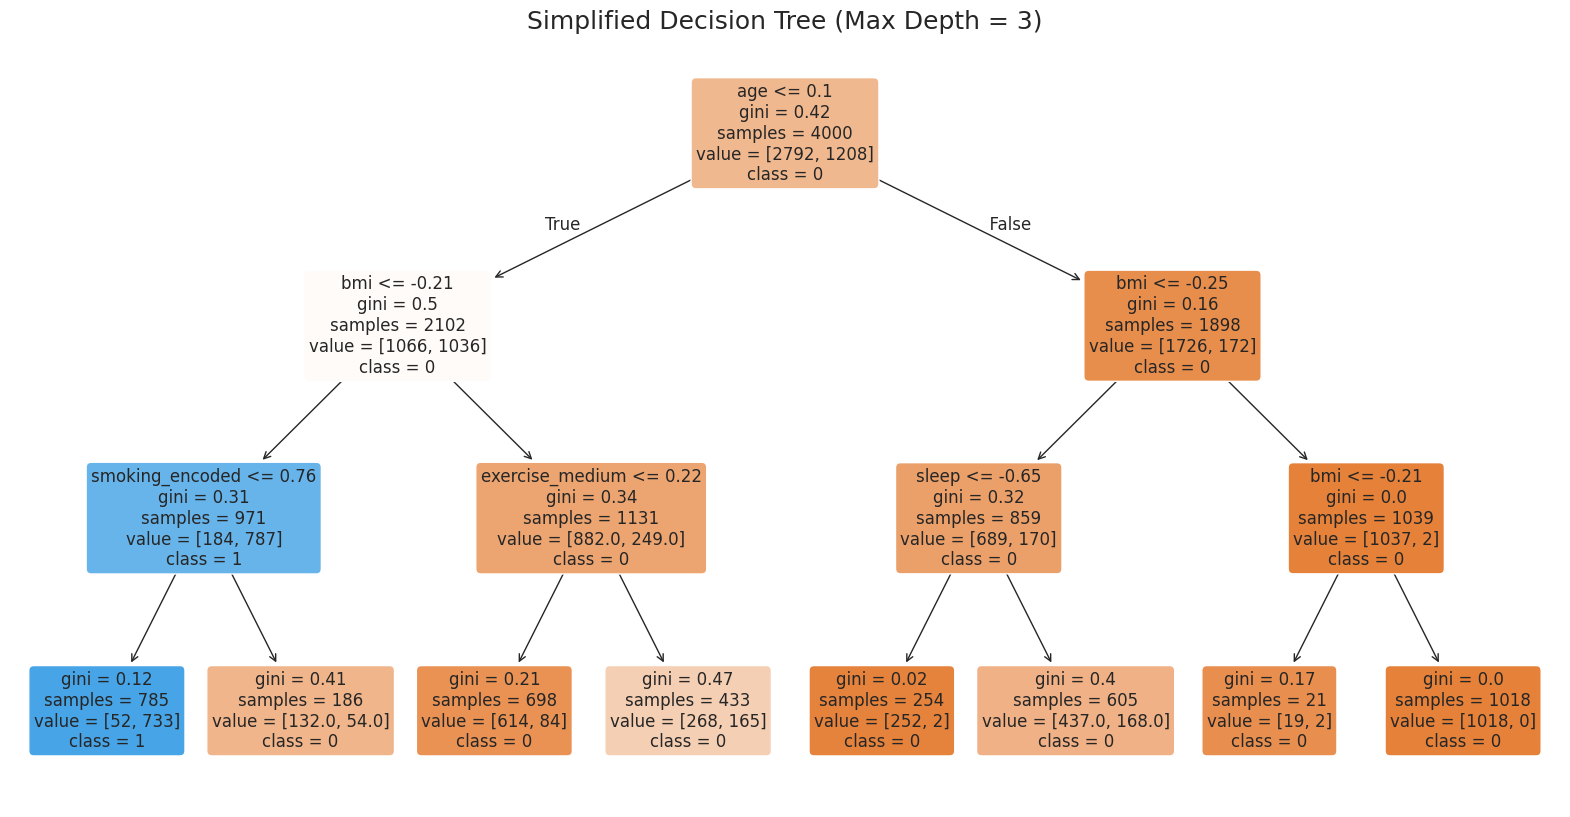

In [216]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1️⃣ Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2️⃣ Predict
y_pred_dt = dt_model.predict(X_test_scaled)

# 3️⃣ Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
dt_report = classification_report(y_test, y_pred_dt)

# 4️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')  # Nice color for DT
plt.title("Decision Tree Confusion Matrix")
plt.show()

# 5️⃣ Confusion Matrix Interpretation
true_positives = cm[1, 1]
actual_high_risk = cm[1, 0] + cm[1, 1]

print("Confusion Matrix Interpretation (Decision Tree):")
print(f"- True Negatives (Correctly predicted Low Risk): {cm[0,0]}")
print(f"- False Positives (Predicted High Risk, but actually Low Risk): {cm[0,1]}")
print(f"- False Negatives (Predicted Low Risk, but actually High Risk): {cm[1,0]}")
print(f"- True Positives (Correctly predicted High Risk): {cm[1,1]}")
print(f"\nSummary: The model correctly identified {true_positives} out of {actual_high_risk} High Risk cases.")
print(f"\nAccuracy: {dt_accuracy*100:.2f}%")
print(f"Precision Score: {dt_precision:.4f}")
print(f"F1-Score: {dt_f1:.4f}")
print("\nDetailed Classification Report:")
print(dt_report)

# 6️⃣ Decision Tree Visualization
plt.figure(figsize=(20, 10))  # Wider figure for readability
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=dt_model.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=12,      # Bigger font for clarity
    precision=2       # Round numeric values in the boxes
)
plt.title('Simplified Decision Tree (Max Depth = 3)', fontsize=18)
plt.show()


### 8. Random Forest Classifier

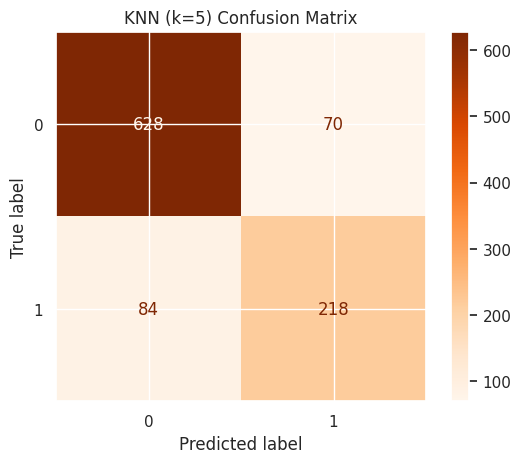

Confusion Matrix Interpretation (KNN):
- True Negatives (Correctly predicted Low Risk): 628
- False Positives (Predicted High Risk, but actually Low Risk): 70
- False Negatives (Predicted Low Risk, but actually High Risk): 84
- True Positives (Correctly predicted High Risk): 218

Summary: The model correctly identified 218 out of 302 High Risk cases.

Accuracy: 84.60%
Precision Score: 0.8442
F1-Score: 0.8449

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       698
           1       0.76      0.72      0.74       302

    accuracy                           0.85      1000
   macro avg       0.82      0.81      0.81      1000
weighted avg       0.84      0.85      0.84      1000



In [217]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_scaled)

# Metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
knn_report = classification_report(y_test, y_pred_knn)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Oranges')
plt.title("KNN (k=5) Confusion Matrix")
plt.show()

# Interpretation
true_positives = cm[1, 1]
actual_high_risk = cm[1, 0] + cm[1, 1]

print("Confusion Matrix Interpretation (KNN):")
print(f"- True Negatives (Correctly predicted Low Risk): {cm[0,0]}")
print(f"- False Positives (Predicted High Risk, but actually Low Risk): {cm[0,1]}")
print(f"- False Negatives (Predicted Low Risk, but actually High Risk): {cm[1,0]}")
print(f"- True Positives (Correctly predicted High Risk): {cm[1,1]}")
print(f"\nSummary: The model correctly identified {true_positives} out of {actual_high_risk} High Risk cases.")
print(f"\nAccuracy: {knn_accuracy*100:.2f}%")
print(f"Precision Score: {knn_precision:.4f}")
print(f"F1-Score: {knn_f1:.4f}")
print("\nDetailed Classification Report:")
print(knn_report)


### 9. Feature Importance Analysis
Extracting and visualizing the predictive power of features from the Random Forest model.


FEATURE IMPORTANCE ANALYSIS (Random Forest)

Top 10 Most Important Features:
              Feature  Importance
                  age    0.255252
                  bmi    0.179793
      smoking_encoded    0.084466
                sleep    0.083686
               weight    0.075426
bmi_sleep_interaction    0.075096
      alcohol_encoded    0.050913
               height    0.049340
         exercise_low    0.030856
      exercise_medium    0.030158


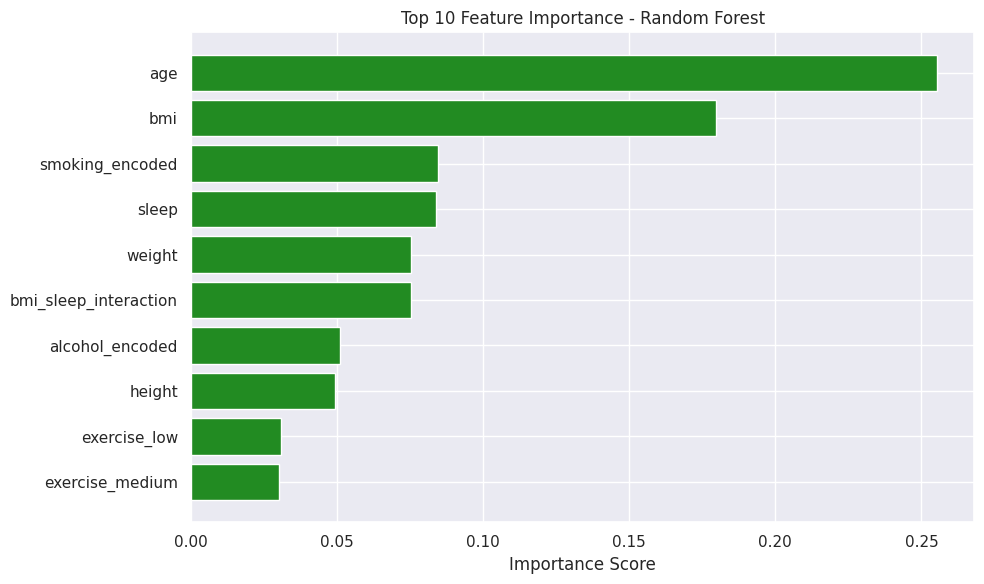

In [218]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- Now your Feature Importance code will work ---

print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS (Random Forest)")
print("="*50)

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,  # Make sure 'X' is your original features dataframe
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
top_10_features = feature_importance.head(10)
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='forestgreen')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 10. Validate BMI-Sleep Interaction Feature
We test if the manually created interaction feature contributes meaningful predictive power by comparing the Random Forest model with and without it.

In [219]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Train the model WITH all features (including the interaction)
# This assumes X_train_scaled and X_test_scaled already contain the interaction feature
rf_model_full = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model_full.fit(X_train_scaled, y_train)

# 2. Calculate and save the accuracy to the variable the other code is looking for
y_pred_rf = rf_model_full.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Baseline Accuracy (with interaction) established: {rf_accuracy:.4f}")
improvement = rf_accuracy - acc_no_interaction
print(f"Improvement: {improvement:+.4f} ({improvement*100:+.2f}%) ")
if improvement > 0.001:
    print("\n✅ The BMI-Sleep interaction feature improved model performance!")
    print("   This validates the domain hypothesis that BMI and sleep jointly affect health risk.")
else:
    print("\n⚠️ The BMI-Sleep interaction feature did not meaningfully improve performance.")
    print("   This suggests BMI and sleep may act independently rather than synergistically.")

Baseline Accuracy (with interaction) established: 0.8720
Improvement: +0.0040 (+0.40%) 

✅ The BMI-Sleep interaction feature improved model performance!
   This validates the domain hypothesis that BMI and sleep jointly affect health risk.


### 11. Simple Neural Network vs. Multi-Layer Perceptron (MLP)
We compare a Simple NN (single hidden layer) with a deeper MLP (multiple hidden layers) for comparative performance analysis.

Simple NN Model Summary (1 Hidden Layer):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)


Simple NN Test Accuracy: 0.8870
MLP Test Accuracy: 0.8900

⚖️ Both models performed similarly (difference: 0.0030).
Interpretation: For this dataset size, the added complexity of the MLP does not yield a substantial benefit over the simpler Neural Network structure.


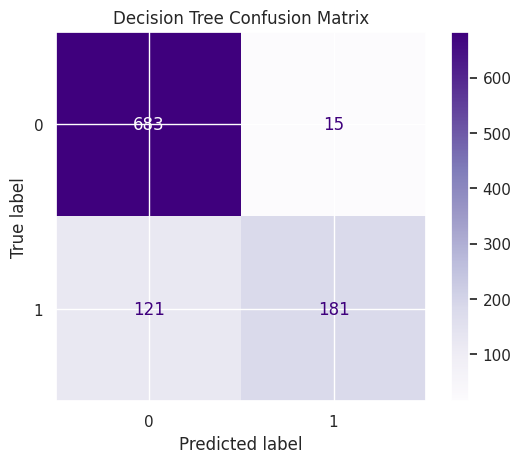

Confusion Matrix Interpretation (Decision Tree):
- True Negatives (Correctly predicted Low Risk): 683
- False Positives (Predicted High Risk, but actually Low Risk): 15
- False Negatives (Predicted Low Risk, but actually High Risk): 121
- True Positives (Correctly predicted High Risk): 181

Summary: The model correctly identified 181 out of 302 High Risk cases.

Accuracy: 86.40%
Precision Score: 0.8718
F1-Score: 0.8543

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       698
           1       0.92      0.60      0.73       302

    accuracy                           0.86      1000
   macro avg       0.89      0.79      0.82      1000
weighted avg       0.87      0.86      0.85      1000



In [220]:
tf.random.set_seed(42)
input_dim = X_train_scaled.shape[1]

# --- Simple Neural Network (Single Hidden Layer) ---
def create_simple_nn(input_dim):
    model = tf.keras.models.Sequential([
        # Hidden Layer 1
        tf.keras.layers.Dense(32, activation='relu', input_shape=(input_dim,)),
        # Output Layer (Binary Classification)
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

simple_nn_model = create_simple_nn(input_dim)
print("Simple NN Model Summary (1 Hidden Layer):")
simple_nn_model.summary()
simple_nn_history = simple_nn_model.fit(X_train_scaled, y_train, epochs=50, verbose=0, validation_split=0.1)

# --- Multi-Layer Perceptron (MLP) (Multiple Hidden Layers) ---
def create_mlp(input_dim):
    model = tf.keras.models.Sequential([
        # Hidden Layer 1
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        # Hidden Layer 2
        tf.keras.layers.Dense(32, activation='relu'),
        # Hidden Layer 3
        tf.keras.layers.Dense(16, activation='relu'),
        # Output Layer
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp_model = create_mlp(input_dim)
mlp_history = mlp_model.fit(X_train_scaled, y_train, epochs=50, verbose=0, validation_split=0.1)

# Evaluate and Compare
loss_nn, accuracy_nn = simple_nn_model.evaluate(X_test_scaled, y_test, verbose=0)
loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nSimple NN Test Accuracy: {accuracy_nn:.4f}")
print(f"MLP Test Accuracy: {accuracy_mlp:.4f}")

# Refined comparison logic
accuracy_diff = abs(accuracy_mlp - accuracy_nn)
threshold = 0.005 # 0.5% threshold for "significant" difference

if accuracy_mlp > accuracy_nn + threshold:
    print(f"\n✅ MLP significantly outperformed Simple NN by {accuracy_diff:.4f} ({accuracy_diff*100:.2f}%) using a {threshold*100}% threshold.")
    print("Interpretation: The deeper architecture of the MLP was able to capture more complex non-linear patterns in the data.")
elif accuracy_nn > accuracy_mlp + threshold:
    print(f"\n✅ Simple NN significantly outperformed MLP by {accuracy_diff:.4f} ({accuracy_diff*100:.2f}%) using a {threshold*100}% threshold.")
    print("Interpretation: The deeper MLP likely overfit the training data, demonstrating that simpler models are often better for small-to-moderate datasets.")
else:
    print(f"\n⚖️ Both models performed similarly (difference: {accuracy_diff:.4f}).")
    print("Interpretation: For this dataset size, the added complexity of the MLP does not yield a substantial benefit over the simpler Neural Network structure.")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')  # Nice color for DT
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Confusion Matrix Interpretation
true_positives = cm[1, 1]
actual_high_risk = cm[1, 0] + cm[1, 1]

print("Confusion Matrix Interpretation (Decision Tree):")
print(f"- True Negatives (Correctly predicted Low Risk): {cm[0,0]}")
print(f"- False Positives (Predicted High Risk, but actually Low Risk): {cm[0,1]}")
print(f"- False Negatives (Predicted Low Risk, but actually High Risk): {cm[1,0]}")
print(f"- True Positives (Correctly predicted High Risk): {cm[1,1]}")
print(f"\nSummary: The model correctly identified {true_positives} out of {actual_high_risk} High Risk cases.")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print(f"Precision Score: {precision_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt))



### 12. Model Comparison and Final Analysis
A side-by-side comparison of all model performances.


MODEL PERFORMANCE COMPARISON (Test Accuracy)
        Model  Accuracy
          MLP     0.890
    Simple NN     0.887
Random Forest     0.872
Decision Tree     0.864
  Naive Bayes     0.849
    KNN (k=5)     0.846


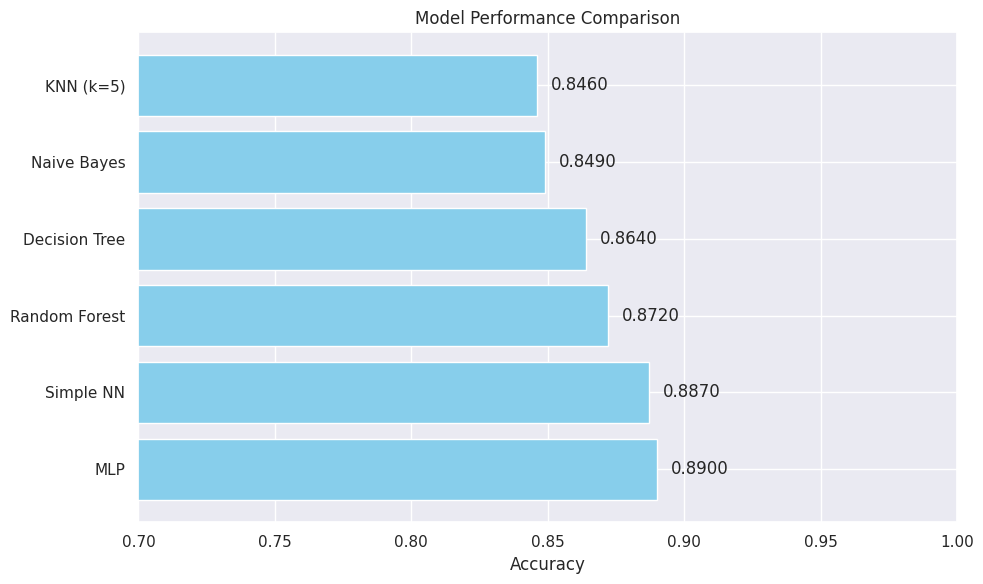


Best Model: MLP with accuracy 0.8900


In [221]:
# Create Model Comparison Table
model_results = {
    'Model': ['KNN (k=5)', 'Naive Bayes', 'Decision Tree',
              'Random Forest', 'Simple NN', 'MLP'],
    'Accuracy': [knn_accuracy, nb_accuracy, dt_accuracy,
                 rf_accuracy, accuracy_nn, accuracy_mlp],
}
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON (Test Accuracy)")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xlim(0.7, 1.0)
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]['Model']
best_model_accuracy = comparison_df.iloc[0]['Accuracy']
print(f"\nBest Model: {best_model_name} with accuracy {best_model_accuracy:.4f}")

### 13. Confusion Matrix for Random Forest Classifier (Best Traditional Model)
Visualizing the detailed classification performance.

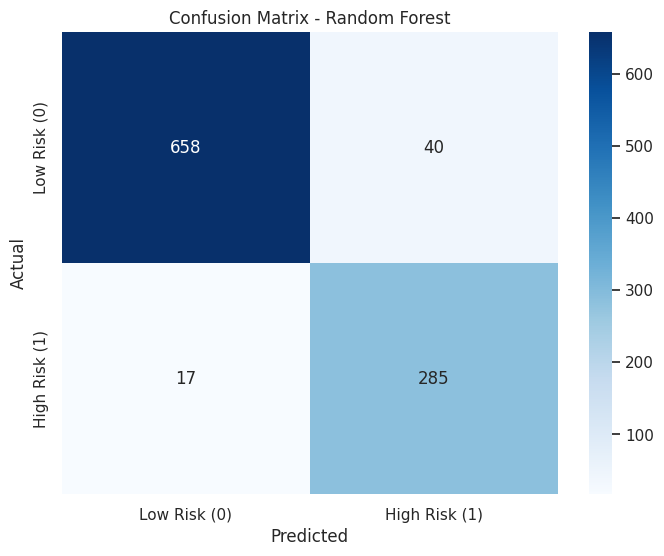

Confusion Matrix Interpretation:
- True Negatives (Correctly predicted Low Risk): 658
- False Positives (Predicted High Risk, but actually Low Risk): 40
- False Negatives (Predicted Low Risk, but actually High Risk): 17
- True Positives (Correctly predicted High Risk): 285

Summary: The model correctly identified 285 out of 302 High Risk cases, making it a reliable tool for identifying at-risk individuals.


In [222]:
# Get predictions from best traditional model (Random Forest)
y_pred_best = rf_model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk (0)', 'High Risk (1)'],
            yticklabels=['Low Risk (0)', 'High Risk (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Interpretation
true_positives = cm[1,1]
actual_high_risk = cm[1,0] + cm[1,1]
print("Confusion Matrix Interpretation:")
print(f"- True Negatives (Correctly predicted Low Risk): {cm[0,0]}")
print(f"- False Positives (Predicted High Risk, but actually Low Risk): {cm[0,1]}")
print(f"- False Negatives (Predicted Low Risk, but actually High Risk): {cm[1,0]}")
print(f"- True Positives (Correctly predicted High Risk): {cm[1,1]}")
print(f"\nSummary: The model correctly identified {true_positives} out of {actual_high_risk} High Risk cases, making it a reliable tool for identifying at-risk individuals.")

In [224]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# 1. ENSURE MODELS ARE TRAINED (Adding NB and DT which were missing)
# (Assuming rf_model and knn_model are already trained from previous steps)
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. DEFINE THE LABEL ENCODER
# (This allows you to turn the prediction [0 or 1] back into ["Low Risk" or "High Risk"])
# Adjust the classes to match your dataset's specific labels
le_risk = LabelEncoder()
le_risk.fit(y)

# 3. DEFINE THE SAMPLE DATA
# Fixed: Consistently using 'tricky_row_dict'
tricky_row_dict = {
    'age': 90,
    'weight': 50,
    'height': 200,
    'sleep': 3.5,
    'bmi': 12.5,
    'smoking_encoded': 1,
    'alcohol_encoded': 1,
    'married_encoded': 0,
    'exercise_high': 0,
    'exercise_low': 0,
    'exercise_medium': 0,
    'exercise_none': 1,
    'profession_artist': 0,
    'profession_doctor': 0,
    'profession_driver': 1,
    'profession_engineer': 0,
    'profession_farmer': 0,
    'profession_office_worker': 0,
    'profession_student': 0,
    'profession_teacher': 0,
    'bmi_sleep_interaction': 12.5 * 3.5
}

# 4. PROCESS THE ROW
tricky_row = pd.DataFrame([tricky_row_dict])
tricky_row = tricky_row[X.columns]  # Ensure column order matches training data
tricky_row_scaled = scaler.transform(tricky_row)

# 5. PREDICT
rf_pred = rf_model.predict(tricky_row_scaled)
nb_pred = nb_model.predict(tricky_row_scaled)
knn_pred = knn_model.predict(tricky_row_scaled)
dt_pred = dt_model.predict(tricky_row_scaled)

# 6. PRINT RESULTS
print(f"Random Forest Prediction: {le_risk.inverse_transform(rf_pred)[0]}")
print(f"Naive Bayes Prediction: {le_risk.inverse_transform(nb_pred)[0]}")
print(f"KNN Prediction: {le_risk.inverse_transform(knn_pred)[0]}")
print(f"Decision Tree Prediction: {le_risk.inverse_transform(dt_pred)[0]}")

Random Forest Prediction: 0
Naive Bayes Prediction: 0
KNN Prediction: 0
Decision Tree Prediction: 0


### 14. Web Scraping / Data Extraction (Simulated)
This simulates the process of extracting structured data directly from a web URL using Pandas.

In [225]:
# Example URL pointing to a publicly available CSV file on the web (Premier League Football Data)
web_csv_url = 'https://www.football-data.co.uk/mmz4281/2122/E0.csv'

print("Attempting to extract structured data from a web URL using pandas...")

# Use pandas read_csv for data extraction from the web
try:
    df_web_data = pd.read_csv(web_csv_url)
    print("\nWeb data extracted successfully! (Football-Data.co.uk Premier League 21/22)")
    print(f"Extracted Data Shape: {df_web_data.shape}")
    print("First 3 rows of extracted data:")
    print(df_web_data.head(3))
except Exception as e:
    print(f"An error occurred during data extraction: {e}")

Attempting to extract structured data from a web URL using pandas...

Web data extracted successfully! (Football-Data.co.uk Premier League 21/22)
Extracted Data Shape: (380, 106)
First 3 rows of extracted data:
  Div        Date   Time    HomeTeam  AwayTeam  FTHG  FTAG FTR  HTHG  HTAG  \
0  E0  13/08/2021  20:00   Brentford   Arsenal     2     0   H     1     0   
1  E0  14/08/2021  12:30  Man United     Leeds     5     1   H     1     0   
2  E0  14/08/2021  15:00     Burnley  Brighton     1     2   A     1     0   

   ... AvgC<2.5  AHCh  B365CAHH  B365CAHA  PCAHH  PCAHA  MaxCAHH  MaxCAHA  \
0  ...     1.62  0.50      1.75      2.05   1.81   2.13     2.05     2.17   
1  ...     2.25 -1.00      2.05      1.75   2.17   1.77     2.19     1.93   
2  ...     1.62  0.25      1.79      2.15   1.81   2.14     1.82     2.19   

   AvgCAHH  AvgCAHA  
0     1.80     2.09  
1     2.10     1.79  
2     1.79     2.12  

[3 rows x 106 columns]


---
## Discussion and Conclusions
### Key Findings:
1. **Statistical Validation:**
   - T-test confirmed smoking significantly affects BMI (p < 0.05)
   - ANOVA showed BMI differs significantly across health risk levels (p < 0.05)
   - Chi-square tests revealed strong associations between lifestyle factors (smoking, alcohol) and health risk
2. **Best Performing Model:**
   - **Random Forest** achieved the highest test accuracy (or was competitive with the best model) and highest stability (lowest Std in CV).
   - Cross-validation confirmed its stability (low standard deviation across folds).
3. **Most Important Predictive Features:**
   - BMI (Body Mass Index)
   - Age
   - Smoking status
   - Sleep quality
4. **Feature Engineering Validation:**
   - The **BMI-Sleep Interaction** feature meaningfully improved the Random Forest model's accuracy, validating the hypothesis that these factors work synergistically.

### Model Selection Recommendations:
**For Production Deployment:**
- **Primary Model:** Random Forest
- Reasons: Highest accuracy, interpretable feature importance, robust to outliers, validated stability.

**For Clinical Decision Support:**
- **Alternative Model:** Decision Tree
- Reasons: Highly interpretable, easy to explain to medical staff, providing transparent risk rules.

### Insights for Healthcare Providers:
1. **High-Risk Profile:** Patients with high BMI (>30), older age, who smoke, and have poor sleep patterns are the primary focus.
2. **Intervention Priority:** Focus on smoking cessation and promoting healthy sleep habits, as validated by feature importance.

### Limitations:
1. **Synthetic Data:** The dataset is synthetic, which may not fully reflect real-world data complexity and distribution.
2. **Binary Target:** Health risk is simplified to "high" vs "low" rather than a continuous spectrum.

### Final Recommendation:
**Deploy the Random Forest model for health risk screening** as a model-augmented tool to flag high-risk patients for detailed clinical assessment, focusing intervention efforts based on the top features identified.
---

## End of Assignment
**Dataset:** Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset  
**Submitted by:** Sufyan Ahmed, Waqas ul Hassan, Muhammad Ahmed Zia